In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_auc_score
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import ADASYN

import warnings
warnings.filterwarnings('ignore')

In [62]:
class AdaBoostADASYNModel:
    def __init__(self, beta=1.5):
        self.beta = beta
        self.pipeline = None
        self.best_threshold = 0.5

    # -------------------------
    # Build Pipeline
    # -------------------------
    def build_pipeline(self):
        
        base_estimator = DecisionTreeClassifier(
            max_depth=1,   # weak learner (decision stump)
            random_state=42
        )

        model = AdaBoostClassifier(
            estimator=base_estimator,
            n_estimators=100,
            learning_rate=0.2,
            random_state=42
        )

        self.pipeline = Pipeline([
            ('scaler', MinMaxScaler()),
            ('adasyn', ADASYN(random_state=42)),
            ('model', model)
        ])

    # -------------------------
    # Hyperparameter Tuning
    # -------------------------
    def tune_model(self, X, y):
        
        param_grid = {
            'model__n_estimators': [50, 100, 150],
            'model__learning_rate': [0.1, 0.5, 1.0]
        }

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        grid = GridSearchCV(
            self.pipeline,
            param_grid,
            cv=skf,
            scoring='f1',  # 🔥 focus on catching attrition
            n_jobs=-1
        )

        grid.fit(X, y)
        self.pipeline = grid.best_estimator_

        print(f"Best Params: {grid.best_params_}")

    # -------------------------
    # Threshold Optimization
    # -------------------------
    def find_best_threshold(self, X, y):

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        y_proba = cross_val_predict(
            self.pipeline,
            X,
            y,
            cv=skf,
            method='predict_proba'
        )[:, 1]

        precision, recall, thresholds = precision_recall_curve(y, y_proba)

        beta = self.beta
        f_beta = (1 + beta**2) * (precision * recall) / ((beta**2 * precision) + recall + 1e-10)

        best_idx = np.argmax(f_beta)
        self.best_threshold = thresholds[best_idx]

        print(f"Best Threshold: {self.best_threshold:.4f}")
        print(f"Best F{beta}: {f_beta[best_idx]:.4f}")

        return precision, recall, best_idx

    # -------------------------
    # Fit
    # -------------------------
    def fit(self, X, y):
        self.pipeline.fit(X, y)

    # -------------------------
    # Predict
    # -------------------------
    def predict(self, X):
        probs = self.predict_proba(X)
        return (probs >= self.best_threshold).astype(int)

    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)[:, 1]

    # -------------------------
    # Evaluate
    # -------------------------
    def evaluate(self, X, y):
        
        y_pred = self.predict(X)
        y_proba = self.predict_proba(X)

        print("\n── Evaluation ──")
        print(classification_report(y, y_pred))
        print(f"ROC-AUC: {roc_auc_score(y, y_proba):.4f}")

        cm = confusion_matrix(y, y_pred)
        disp = ConfusionMatrixDisplay(cm)
        disp.plot()
        plt.title("Confusion Matrix")
        plt.show()

    # -------------------------
    # PR Curve
    # -------------------------
    def plot_pr_curve(self, precision, recall, best_idx):
        
        plt.figure(figsize=(7,5))
        plt.plot(recall, precision)
        plt.scatter(recall[best_idx], precision[best_idx], label="Best Point")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision-Recall Curve")
        plt.legend()
        plt.show()

In [63]:
# Load Data
df = pd.read_csv('../data/Processed_HR_Employee_Attrition.csv')

In [64]:
# Encode
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df = pd.get_dummies(df, drop_first=True)

In [70]:
# Split
X = df.drop(columns='Attrition')
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

In [71]:
# Initialize Model
model = AdaBoostADASYNModel(beta=1)
model.build_pipeline()

/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/utkarshuday/Desktop/employee-attrition/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn dev

Best Params: {'model__learning_rate': 0.5, 'model__n_estimators': 150}
Best Threshold: 0.5004
Best F1: 0.6163


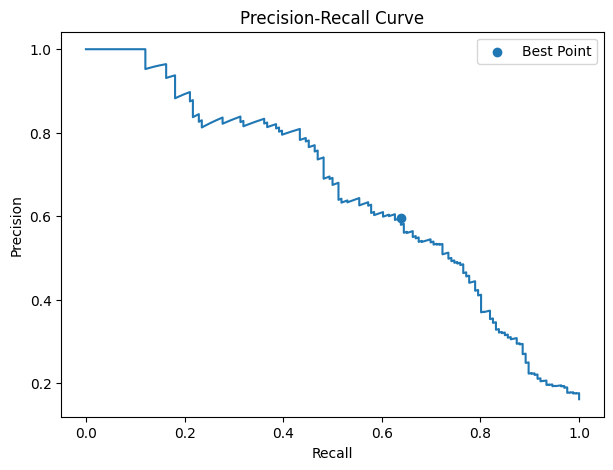

In [72]:
# Tune
model.tune_model(X_train, y_train)

# Find Threshold
precision, recall, best_idx = model.find_best_threshold(X_train, y_train)
model.plot_pr_curve(precision, recall, best_idx)

# Fit Final Model
model.fit(X_train, y_train)


── Evaluation ──
              precision    recall  f1-score   support

           0       0.90      0.89      0.90       370
           1       0.46      0.48      0.47        71

    accuracy                           0.83       441
   macro avg       0.68      0.69      0.68       441
weighted avg       0.83      0.83      0.83       441

ROC-AUC: 0.7963


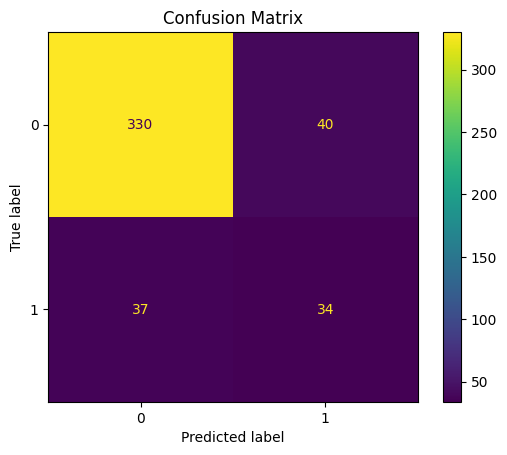

[0.28007894 0.38413863 0.4341849  0.48645986 0.51542455 0.54084679
 0.58794178]


In [73]:
# Evaluate
model.evaluate(X_test, y_test)

# Debug probabilities
y_test_proba = model.predict_proba(X_test)
print(np.percentile(y_test_proba, [0, 25, 50, 75, 90, 95, 99]))

In [69]:
y_test_proba = model.predict_proba(X_test)

for t in [0.3, 0.4, 0.5, 0.51,0.578, 0.58, 0.585,0.59, 0.6,0.7]:
    y_pred = (y_test_proba >= t).astype(int)
    
    print(f"\nThreshold = {t:.3f}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_pred):.4f}")


Threshold = 0.300
[[  5 242]
 [  1  46]]
              precision    recall  f1-score   support

           0       0.83      0.02      0.04       247
           1       0.16      0.98      0.27        47

    accuracy                           0.17       294
   macro avg       0.50      0.50      0.16       294
weighted avg       0.73      0.17      0.08       294

ROC-AUC: 0.4995

Threshold = 0.400
[[ 85 162]
 [  4  43]]
              precision    recall  f1-score   support

           0       0.96      0.34      0.51       247
           1       0.21      0.91      0.34        47

    accuracy                           0.44       294
   macro avg       0.58      0.63      0.42       294
weighted avg       0.84      0.44      0.48       294

ROC-AUC: 0.6295

Threshold = 0.500
[[215  32]
 [ 19  28]]
              precision    recall  f1-score   support

           0       0.92      0.87      0.89       247
           1       0.47      0.60      0.52        47

    accuracy            